# 12. Simulation Labs for Assumption Stress Testing

A single synthetic dataset can teach a causal idea. A simulation lab does something more powerful: it lets us deliberately vary the assumptions and watch estimators fail in predictable ways.

This notebook builds an assumption stress-testing lab for an industry causal problem. We will simulate a customer-success intervention where treatment assignment is observational, overlap can be good or bad, some confounding is observed, some confounding can be hidden, outcomes can be missing selectively, and account outcomes can be affected by team-level spillovers.

The goal is not to make a perfect business simulator. The goal is to create a controlled environment where causal assumptions become visible.

## Mathematical Core

A stress test varies one assumption-strength parameter at a time and tracks estimator behavior. Let $\gamma$ control unobserved confounding, overlap, interference, or measurement error. For each value of $\gamma$, compute

$$
\mathrm{bias}(\gamma) = \mathbb{E}[\hat\tau(\gamma)] - \tau(\gamma),
$$

and empirical coverage,

$$
\widehat{\mathrm{coverage}}(\gamma) = \frac{1}{B} \sum_{b=1}^{B} \mathbf{1}\{\tau(\gamma) \in CI_b(\gamma)\}.
$$

The lab is therefore a controlled experiment over assumptions. It teaches which diagnostics fail gracefully and which ones collapse when the data-generating process moves away from the ideal case.


## Learning Goals

By the end of this notebook you should be able to:

1. Explain the difference between a single synthetic dataset and a simulation stress-test lab.
2. Build a parameterized data-generating process where assumption violations can be dialed up or down.
3. Stress test ignorability, overlap, measurement validity, selection, and interference.
4. Compare naive, observed-adjusted, oracle-adjusted, and selected-sample estimators against ground truth.
5. Create scenario grids and visualize how estimator bias changes across assumptions.
6. Use an LLM to review simulation-lab results without letting it overclaim real-world validity.
7. Audit AI outputs for brittle causal reasoning, missing limitations, and dangerous recommendations.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Simulation labs make brittleness especially visible. The Python lab can tell us exactly which assumption was violated and how much bias appeared. The LLM may still summarize the result too confidently, miss a limitation, or confuse an oracle estimator with a feasible real-world estimator. We will keep those failures inspectable.

## 1. Setup

The deterministic part of this notebook uses simulation, regression, and plotting. The optional AI section uses the same shared local model runtime as previous Course 05 notebooks.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)

from notebooks._shared.display import smart_display


In [2]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 1800
TEMPERATURE = 0.0
SEED = 212
MODEL_COMPARISON_CASE_LIMIT = 1

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 150)

In [3]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def has_package(module_name):
    """Carry out the has package step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    module_name : object
        Name of the Python package or notebook module being checked for availability.
    
    Returns
    -------
    object
        Intermediate result produced by the has package calculation and reused by later cells.
    """
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'numpy', 'available': has_package('numpy'), 'used_for': 'simulation lab DGP'},
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'scenario tables'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'estimator comparisons'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'stress-test plots'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI review schema'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
smart_display(package_status)

CUDA available to this kernel: True


,package,available,used_for
0,numpy,True,simulation lab DGP
1,pandas,True,scenario tables
2,statsmodels,True,estimator comparisons
3,seaborn,True,stress-test plots
4,pydantic,True,structured AI review schema
5,transformers,True,optional local LLM review
6,torch,True,GPU inference if live LLMs are enabled


## 2. From Synthetic Example to Simulation Lab

A synthetic example usually asks:

> Can we show a specific causal failure mode?

A simulation lab asks:

> How does estimator behavior change as assumptions become more or less plausible?

That shift matters. A lab lets us map bias over a grid of conditions: hidden confounding, poor overlap, measurement error, selection, and spillovers. It turns assumptions from abstract warnings into empirical objects.

In [4]:
# Section focus: 2. From Synthetic Example to Simulation Lab.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

stress_test_dimensions = pd.DataFrame(
    [
        {
            'assumption': 'Conditional exchangeability',
            'stress knob': 'unobserved_confounding_strength',
            'what gets worse': 'Treatment depends on hidden account attention that also affects renewal.',
            'expected pattern': 'Observed adjustment remains biased; oracle adjustment recovers the truth better.',
        },
        {
            'assumption': 'Positivity / overlap',
            'stress knob': 'overlap_pressure',
            'what gets worse': 'High-risk accounts are almost always treated and low-risk accounts are almost never treated.',
            'expected pattern': 'Estimates become unstable and target-population interpretation weakens.',
        },
        {
            'assumption': 'Measurement validity',
            'stress knob': 'measurement_error_sd',
            'what gets worse': 'Observed health score becomes a noisier proxy for true account health.',
            'expected pattern': 'Adjustment with noisy proxies leaves residual confounding.',
        },
        {
            'assumption': 'No selection on post-treatment variables',
            'stress knob': 'selection_strength',
            'what gets worse': 'Outcome observation depends on treatment and latent renewal propensity.',
            'expected pattern': 'Complete-case analysis targets a selected sample.',
        },
        {
            'assumption': 'No interference',
            'stress knob': 'spillover_strength',
            'what gets worse': 'An account outcome depends on treatment saturation in the customer-success team.',
            'expected pattern': 'Individual-level estimators mix direct and spillover effects.',
        },
    ]
)
smart_display(stress_test_dimensions)

,assumption,stress knob,what gets worse,expected pattern
0,Conditional exchangeability,unobserved_confounding_strength,Treatment depends on hidden account attention that also affects renewal.,Observed adjustment remains biased; oracle adjustment recovers the truth better.
1,Positivity / overlap,overlap_pressure,High-risk accounts are almost always treated and low-risk accounts are almost never treated.,Estimates become unstable and target-population interpretation weakens.
2,Measurement validity,measurement_error_sd,Observed health score becomes a noisier proxy for true account health.,Adjustment with noisy proxies leaves residual confounding.
3,No selection on post-treatment variables,selection_strength,Outcome observation depends on treatment and latent renewal propensity.,Complete-case analysis targets a selected sample.
4,No interference,spillover_strength,An account outcome depends on treatment saturation in the customer-success team.,Individual-level estimators mix direct and spillover effects.


The most important habit is to name the assumption before building the simulation. Otherwise, synthetic data can become a pile of knobs without a causal lesson.

A good stress test has this form: if the assumption is violated in this specific way, this estimator should fail in this specific direction or become less stable.

## 3. Running Example: Customer-Success Playbook

A SaaS company deploys a customer-success playbook to accounts thought to be at risk of non-renewal. The business question is:

> What is the total effect of receiving the playbook on 90-day renewal?

The analyst observes account size, usage trend, support tickets, segment, region, and a noisy health score. The simulation also contains hidden executive attention, true account health, team-level treatment saturation, and the potential outcomes. Those are available only because this is a synthetic lab.

In [5]:
lab_card = {
    'title': 'Customer-success playbook stress-test lab',
    'unit': 'account',
    'cluster': 'customer_success_team',
    'treatment': 'playbook_assigned',
    'outcome': 'renewed_90d',
    'estimand': 'ATE of playbook_assigned on renewed_90d in the simulated account population',
    'observed_confounders': ['segment', 'region', 'account_size', 'usage_trend', 'support_tickets', 'observed_health_score', 'risk_score_observed'],
    'hidden_variables': ['true_account_health', 'executive_attention'],
    'post_treatment_or_selection_variables': ['playbook_engagement', 'expansion_call_completed', 'outcome_observed'],
    'simulation_warning': 'Oracle variables are included for teaching only and would not be observed in a real analysis.',
}

print(json.dumps(lab_card, indent=2))

{
  "title": "Customer-success playbook stress-test lab",
  "unit": "account",
  "cluster": "customer_success_team",
  "treatment": "playbook_assigned",
  "outcome": "renewed_90d",
  "estimand": "ATE of playbook_assigned on renewed_90d in the simulated account population",
  "observed_confounders": [
    "segment",
    "region",
    "account_size",
    "usage_trend",
    "support_tickets",
    "observed_health_score",
    "risk_score_observed"
  ],
  "hidden_variables": [
    "true_account_health",
    "executive_attention"
  ],
  "post_treatment_or_selection_variables": [
    "playbook_engagement",
    "expansion_call_completed",
    "outcome_observed"
  ],
  "simulation_warning": "Oracle variables are included for teaching only and would not be observed in a real analysis."
}


This checkpoint connects computation to judgment. In Running Example: Customer-Success Playbook, the useful question is what the result would change in the workflow: the model, the threshold, the data audit, the explanation, or the stakeholder recommendation. A result with no action attached is incomplete for decision science.


## 4. Parameterized Data-Generating Process

The DGP below exposes five stress knobs:

- `unobserved_confounding_strength`: how strongly hidden executive attention affects assignment and outcome.
- `overlap_pressure`: how deterministic treatment targeting becomes.
- `measurement_error_sd`: how noisy the observed health score is.
- `selection_strength`: how strongly outcome observation depends on treatment and renewal propensity.
- `spillover_strength`: how much team-level treatment saturation affects account outcomes.

The true ATE is computed from potential outcomes. Estimators only see the observed outcome.

In [6]:
# Section focus: 4. Parameterized Data-Generating Process.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def simulate_playbook_lab(
    n_accounts=5000,
    n_teams=80,
    seed=SEED,
    unobserved_confounding_strength=0.6,
    overlap_pressure=1.0,
    measurement_error_sd=0.45,
    selection_strength=0.4,
    spillover_strength=0.05,
):
    """Create a simulated playbook lab data set for the 12. Simulation Labs for Assumption Stress Testing case study.
    
    Parameters
    ----------
    n_accounts : object
        Number of account records to create for the simulated business setting.
    n_teams : object
        Count or size setting for the playbook lab calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    unobserved_confounding_strength : object
        The unobserved confounding strength setting that controls the playbook lab calculation in this notebook.
    overlap_pressure : object
        The overlap pressure setting that controls the playbook lab calculation in this notebook.
    measurement_error_sd : object
        The measurement error sd setting that controls the playbook lab calculation in this notebook.
    selection_strength : object
        The selection strength setting that controls the playbook lab calculation in this notebook.
    spillover_strength : object
        The spillover strength setting that controls the playbook lab calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    team_id = rng.integers(0, n_teams, size=n_accounts)
    team_quality = rng.normal(0, 0.55, size=n_teams)
    segment = rng.choice(['startup', 'midmarket', 'enterprise'], size=n_accounts, p=[0.46, 0.37, 0.17])
    region = rng.choice(['Americas', 'EMEA', 'APAC'], size=n_accounts, p=[0.48, 0.33, 0.19])
    account_size = np.exp(3.25 + 0.42 * (segment == 'enterprise') + 0.18 * (segment == 'midmarket') + rng.normal(0, 0.45, size=n_accounts))
    usage_trend = rng.normal(0, 1, size=n_accounts)
    support_tickets = rng.poisson(np.exp(-0.15 - 0.20 * usage_trend + 0.25 * (segment == 'enterprise')), size=n_accounts)
    true_account_health = (
        0.65 * usage_trend
        - 0.32 * support_tickets
        + 0.22 * (segment == 'enterprise')
        + 0.12 * (region == 'Americas')
        + team_quality[team_id]
        + rng.normal(0, 0.55, size=n_accounts)
    )
    observed_health_score = true_account_health + rng.normal(0, measurement_error_sd, size=n_accounts)
    executive_attention = rng.normal(0, 1, size=n_accounts)
    risk_score_observed = -0.85 * observed_health_score + 0.30 * support_tickets + 0.10 * np.log1p(account_size) + rng.normal(0, 0.35, size=n_accounts)

    assignment_logit = (
        -0.20
        + overlap_pressure * (1.10 * risk_score_observed + 0.18 * np.log1p(account_size) + 0.18 * (segment == 'enterprise'))
        + unobserved_confounding_strength * executive_attention
        + 0.20 * team_quality[team_id]
        + rng.normal(0, 0.65, size=n_accounts)
    )
    propensity_true = sigmoid(assignment_logit)
    playbook_assigned = rng.binomial(1, propensity_true)

    team_treatment_rate = pd.Series(playbook_assigned).groupby(team_id).transform('mean').to_numpy()
    direct_effect = 0.055 + 0.035 * sigmoid(risk_score_observed) + 0.012 * (segment == 'enterprise')
    p0 = sigmoid(
        -0.05
        + 0.95 * true_account_health
        + 0.12 * np.log1p(account_size)
        - 0.18 * support_tickets
        + 0.16 * team_quality[team_id]
        + unobserved_confounding_strength * 0.35 * executive_attention
        + spillover_strength * team_treatment_rate
    )
    p1 = sigmoid(
        -0.05
        + 0.95 * true_account_health
        + 0.12 * np.log1p(account_size)
        - 0.18 * support_tickets
        + 0.16 * team_quality[team_id]
        + unobserved_confounding_strength * 0.35 * executive_attention
        + direct_effect
        + spillover_strength * team_treatment_rate
    )
    renewed_probability = np.where(playbook_assigned == 1, p1, p0)
    renewed_90d = rng.binomial(1, renewed_probability)

    playbook_engagement = rng.binomial(1, sigmoid(-1.0 + 1.4 * playbook_assigned + 0.35 * observed_health_score - 0.25 * risk_score_observed))
    expansion_call_completed = rng.binomial(1, sigmoid(-1.4 + 1.1 * playbook_assigned + 0.45 * playbook_engagement + 0.15 * np.log1p(account_size)))
    outcome_observed = rng.binomial(
        1,
        sigmoid(2.2 + selection_strength * (0.9 * playbook_assigned + 1.25 * renewed_probability - 0.45 * support_tickets)),
    )
    renewed_90d_observed = renewed_90d.astype(float)
    renewed_90d_observed[outcome_observed == 0] = np.nan

    df = pd.DataFrame(
        {
            'account_id': [f'A{idx:05d}' for idx in range(n_accounts)],
            'team_id': [f'T{idx:03d}' for idx in team_id],
            'segment': segment,
            'region': region,
            'account_size': account_size,
            'usage_trend': usage_trend,
            'support_tickets': support_tickets,
            'observed_health_score': observed_health_score,
            'risk_score_observed': risk_score_observed,
            'true_account_health': true_account_health,
            'executive_attention': executive_attention,
            'team_quality': team_quality[team_id],
            'propensity_true': propensity_true,
            'team_treatment_rate': team_treatment_rate,
            'playbook_assigned': playbook_assigned,
            'p0_renewal': p0,
            'p1_renewal': p1,
            'true_individual_effect': p1 - p0,
            'playbook_engagement': playbook_engagement,
            'expansion_call_completed': expansion_call_completed,
            'outcome_observed': outcome_observed,
            'renewed_90d': renewed_90d,
            'renewed_90d_observed': renewed_90d_observed,
        }
    )
    truth = {
        'true_ate': float(np.mean(df['true_individual_effect'])),
        'true_att': float(df.loc[df['playbook_assigned'].eq(1), 'true_individual_effect'].mean()),
        'treatment_rate': float(df['playbook_assigned'].mean()),
        'complete_outcome_rate': float(df['outcome_observed'].mean()),
        'overlap_share_10_to_90': float(((df['propensity_true'] > 0.10) & (df['propensity_true'] < 0.90)).mean()),
    }
    return df, truth

base_df, base_truth = simulate_playbook_lab()
base_df.head()

,account_id,team_id,segment,region,account_size,usage_trend,support_tickets,observed_health_score,risk_score_observed,true_account_health,...,team_treatment_rate,playbook_assigned,p0_renewal,p1_renewal,true_individual_effect,playbook_engagement,expansion_call_completed,outcome_observed,renewed_90d,renewed_90d_observed
0,A00000,T000,startup,Americas,37.517987,1.439315,0,1.178618,-0.380829,1.212183,...,0.734940,1,0.839394,0.848506,0.009112,1,1,1,1,1.0
1,A00001,T045,startup,APAC,16.434040,0.818395,0,0.280338,0.472959,-0.008347,...,0.718750,1,0.640833,0.658259,0.017426,1,1,1,1,1.0
2,A00002,T063,midmarket,Americas,50.060822,1.823837,1,1.094824,-0.163808,1.464695,...,0.642857,0,0.803594,0.814569,0.010976,1,0,1,1,1.0
3,A00003,T023,startup,EMEA,21.857387,0.139223,2,-1.468504,2.574575,-1.494653,...,0.774194,1,0.213587,0.228656,0.015069,0,0,1,0,0.0
4,A00004,T024,startup,Americas,24.268110,0.099540,1,-0.543321,1.647157,-0.094989,...,0.704918,1,0.641542,0.660699,0.019157,0,1,1,1,1.0


Treat this output as evidence about the AI-assisted workflow. In Parameterized Data-Generating Process, check whether the response stays grounded, preserves the estimand or task contract, and names uncertainty. A repair is useful when it leaves behind a check for the next run.


In [7]:
smart_display(base_truth)

{'true_ate': 0.015764260540234283,
 'true_att': 0.016116169667775584,
 'treatment_rate': 0.7176,
 'complete_outcome_rate': 0.9258,
 'overlap_share_10_to_90': 0.711}

The simulation includes variables that would be observed in a real analysis and variables that exist only because we are in a synthetic lab. The oracle variables help us diagnose failure modes. They are not part of a feasible production estimator.

Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Parameterized Data-Generating Process. Read the table for diagnostic consequences rather than size alone.


## 5. Variable Role Map

A stress-test lab needs a role map. Otherwise, it is too easy to accidentally treat oracle variables, mediators, or selection indicators as ordinary controls.

| variable | timing | role | feasible_primary_adjustment |
|---|---|---|---|
| account_id | unit id | identifier | no |
| team_id | pre-treatment cluster | cluster identifier | maybe fixed effects or clustering |
| segment | pre-treatment | observed confounder candidate | yes |
| region | pre-treatment | observed confounder candidate | yes |
| account_size | pre-treatment | observed confounder candidate | yes |
| usage_trend | pre-treatment | observed confounder candidate | yes |
| support_tickets | pre-treatment | observed confounder candidate | yes |
| observed_health_score | pre-treatment | noisy confounder proxy | yes |
| risk_score_observed | pre-treatment | assignment proxy | yes |
| true_account_health | latent pre-treatment | oracle hidden confounder | oracle only |
| executive_attention | latent pre-treatment | oracle hidden confounder | oracle only |
| team_quality | latent/team-level pre-treatment | oracle team variable | oracle only |
| propensity_true | latent assignment | oracle propensity | oracle only |
| team_treatment_rate | post-assignment cluster saturation | interference/spillover diagnostic | not a primary individual control |
| playbook_assigned | treatment | treatment | no |
| p0_renewal | potential outcome | oracle truth | oracle only |
| p1_renewal | potential outcome | oracle truth | oracle only |
| true_individual_effect | potential outcome contrast | oracle truth | oracle only |
| playbook_engagement | post-treatment | mediator or compliance behavior | no |
| expansion_call_completed | post-treatment | mediator | no |
| outcome_observed | post-treatment/selection | selection indicator | no |
| renewed_90d | outcome | true observed outcome in full synthetic data | no |
| renewed_90d_observed | outcome with missingness | observed outcome in selected sample | no |


## 6. Base Scenario Diagnostics

Before running a scenario grid, inspect the base case. We want to see overlap, selection, and treatment imbalance.

The base scenario is the reference world for the stress test. It should be realistic enough to contain targeted treatment assignment, incomplete overlap, noisy health measurement, and some outcome selection, but not so extreme that every estimator immediately fails. That makes it a useful starting point for asking what changes as one assumption becomes weaker.

These diagnostics are the safety check before the grid. If the base case already has severe non-overlap or almost deterministic treatment, then later bias patterns may be driven by a broken starting point rather than the stress knob we intended to study.


In [9]:
base_summary = pd.DataFrame(
    [
        {'metric': 'rows', 'value': len(base_df)},
        {'metric': 'treatment rate', 'value': base_truth['treatment_rate']},
        {'metric': 'true ATE', 'value': base_truth['true_ate']},
        {'metric': 'true ATT', 'value': base_truth['true_att']},
        {'metric': 'complete outcome rate', 'value': base_truth['complete_outcome_rate']},
        {'metric': 'propensity overlap share 0.10-0.90', 'value': base_truth['overlap_share_10_to_90']},
    ]
)
smart_display(base_summary)

,metric,value
0,rows,5000.000000
1,treatment rate,0.717600
2,true ATE,0.015764
3,true ATT,0.016116
4,complete outcome rate,0.925800
5,propensity overlap share 0.10-0.90,0.711000


These numbers translate model behavior into decision consequences. For Base Scenario Diagnostics, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


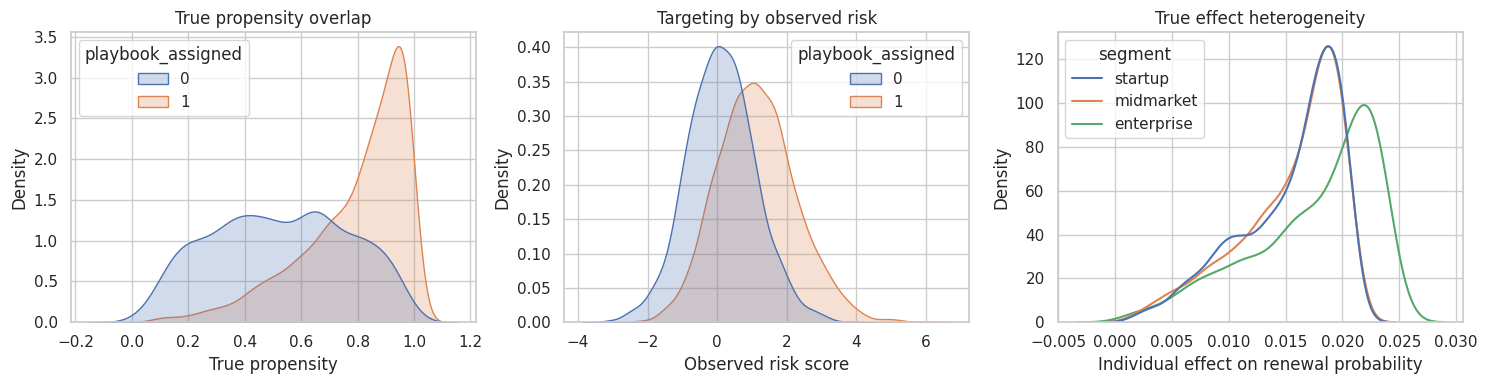

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.kdeplot(data=base_df, x='propensity_true', hue='playbook_assigned', common_norm=False, fill=True, alpha=0.25, ax=axes[0])
axes[0].set_title('True propensity overlap')
axes[0].set_xlabel('True propensity')

sns.kdeplot(data=base_df, x='risk_score_observed', hue='playbook_assigned', common_norm=False, fill=True, alpha=0.25, ax=axes[1])
axes[1].set_title('Targeting by observed risk')
axes[1].set_xlabel('Observed risk score')

sns.kdeplot(data=base_df, x='true_individual_effect', hue='segment', common_norm=False, fill=False, ax=axes[2])
axes[2].set_title('True effect heterogeneity')
axes[2].set_xlabel('Individual effect on renewal probability')
plt.tight_layout()
plt.show()

The graphic gives us a way to see where the summary number is too compressed. For Base Scenario Diagnostics, look for where groups separate, where curves bend, or where the tails behave differently. The next decision should reflect these features, the aggregate score alone.


In [11]:
# Section focus: 6. Base Scenario Diagnostics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def standardized_mean_difference(df, treatment_col, variables):
    """Carry out the standardized mean difference step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    treatment_col : object
        Column name containing the treatment or intervention indicator.
    variables : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        Intermediate result produced by the standardized mean difference calculation and reused by later cells.
    """
    rows = []
    treated = df[df[treatment_col].eq(1)]
    control = df[df[treatment_col].eq(0)]
    for variable in variables:
        t = treated[variable].dropna()
        c = control[variable].dropna()
        pooled_sd = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
        smd = np.nan if pooled_sd == 0 or np.isnan(pooled_sd) else (t.mean() - c.mean()) / pooled_sd
        rows.append({'variable': variable, 'smd': smd, 'abs_smd': abs(smd) if not np.isnan(smd) else np.nan})
    return pd.DataFrame(rows).sort_values('abs_smd', ascending=False)

observed_covariates = ['account_size', 'usage_trend', 'support_tickets', 'observed_health_score', 'risk_score_observed']
base_balance = standardized_mean_difference(base_df, 'playbook_assigned', observed_covariates + ['true_account_health', 'executive_attention'])
smart_display(base_balance)

,variable,smd,abs_smd
4,risk_score_observed,0.957224,0.957224
3,observed_health_score,-0.846343,0.846343
5,true_account_health,-0.751668,0.751668
2,support_tickets,0.536961,0.536961
1,usage_trend,-0.465969,0.465969
6,executive_attention,0.418511,0.418511
0,account_size,0.080237,0.080237


The balance table includes oracle variables for diagnosis. In a real dataset, the analyst would not see `true_account_health` or `executive_attention`. If those hidden variables are imbalanced and affect the outcome, observed adjustment may not remove all bias.

Putting the choices in one table makes the section easier to check. For Base Scenario Diagnostics, the important reading is the pattern across rows, the pattern across rows together with the largest values. A useful pattern points to a specific diagnostic or policy update.


## 7. Estimator Set

We define a common estimator set for every scenario:

- **Naive:** outcome on treatment only.
- **Observed adjustment:** adjusts for feasible observed pre-treatment covariates.
- **Oracle adjustment:** additionally adjusts for hidden variables. This is for diagnosis only.
- **Bad post-treatment adjustment:** adds mediator variables. This answers the wrong question.
- **Complete-case observed adjustment:** uses the selected observed outcome only.

All estimates are compared against the true ATE.

In [12]:
# Section focus: 7. Estimator Set.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

OBSERVED_FORMULA = (
    'renewed_90d ~ playbook_assigned + account_size + usage_trend + support_tickets + '
    'observed_health_score + risk_score_observed + C(segment) + C(region)'
)
ORACLE_FORMULA = OBSERVED_FORMULA + ' + true_account_health + executive_attention + team_quality'
BAD_POST_FORMULA = OBSERVED_FORMULA + ' + playbook_engagement + expansion_call_completed'


def estimate_scenario(df, truth):
    """Estimate scenario for the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    truth : object
        The truth setting that controls the scenario calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    specs = {
        'naive': 'renewed_90d ~ playbook_assigned',
        'observed adjustment': OBSERVED_FORMULA,
        'oracle hidden adjustment': ORACLE_FORMULA,
        'bad post-treatment adjustment': BAD_POST_FORMULA,
    }
    for label, formula in specs.items():
        fitted = smf.ols(formula, data=df).fit(cov_type='HC3')
        effect = fitted.params.get('playbook_assigned', np.nan)
        rows.append(
            {
                'estimator': label,
                'rows_used': int(fitted.nobs),
                'estimated_effect': effect,
                'robust_se': fitted.bse.get('playbook_assigned', np.nan),
                'true_ate': truth['true_ate'],
                'bias': effect - truth['true_ate'],
                'absolute_bias': abs(effect - truth['true_ate']),
                'r_squared': fitted.rsquared,
            }
        )

    complete_case = df.dropna(subset=['renewed_90d_observed']).copy()
    cc_formula = OBSERVED_FORMULA.replace('renewed_90d', 'renewed_90d_observed')
    fitted = smf.ols(cc_formula, data=complete_case).fit(cov_type='HC3')
    effect = fitted.params.get('playbook_assigned', np.nan)
    rows.append(
        {
            'estimator': 'complete-case observed adjustment',
            'rows_used': int(fitted.nobs),
            'estimated_effect': effect,
            'robust_se': fitted.bse.get('playbook_assigned', np.nan),
            'true_ate': truth['true_ate'],
            'bias': effect - truth['true_ate'],
            'absolute_bias': abs(effect - truth['true_ate']),
            'r_squared': fitted.rsquared,
        }
    )
    return pd.DataFrame(rows)

base_estimates = estimate_scenario(base_df, base_truth)
smart_display(base_estimates)

,estimator,rows_used,estimated_effect,robust_se,true_ate,bias,absolute_bias,r_squared
0,naive,5000,-0.146202,0.015415,0.015764,-0.161966,0.161966,0.017331
1,observed adjustment,5000,0.028192,0.015590,0.015764,0.012428,0.012428,0.190020
2,oracle hidden adjustment,5000,0.000631,0.015557,0.015764,-0.015134,0.015134,0.221213
3,bad post-treatment adjustment,5000,0.023009,0.016459,0.015764,0.007244,0.007244,0.190383
4,complete-case observed adjustment,4629,0.021847,0.016250,0.015764,0.006083,0.006083,0.186229


This table gives the quantitative checkpoint for Estimator Set. Use the rows to compare practical consequences as well as scores. Concentrated failures are useful because they tell the analyst where the workflow needs a closer look.


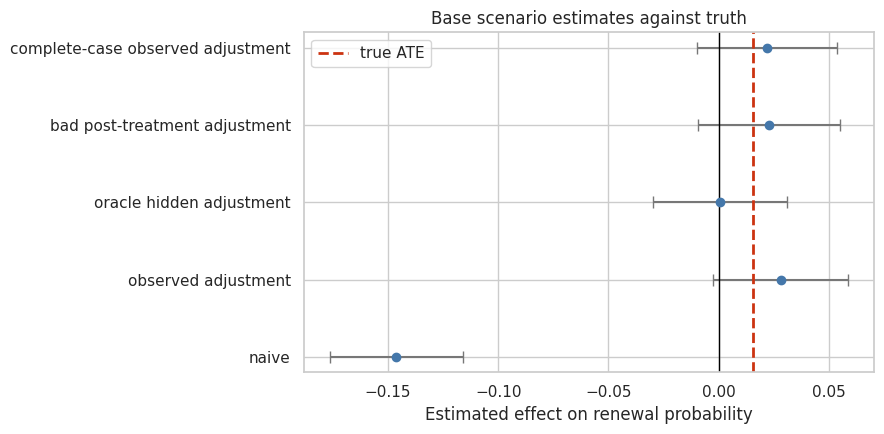

In [13]:
plot_estimates = base_estimates.assign(
    lower=lambda d: d['estimated_effect'] - 1.96 * d['robust_se'],
    upper=lambda d: d['estimated_effect'] + 1.96 * d['robust_se'],
)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(
    plot_estimates['estimated_effect'],
    plot_estimates['estimator'],
    xerr=[plot_estimates['estimated_effect'] - plot_estimates['lower'], plot_estimates['upper'] - plot_estimates['estimated_effect']],
    fmt='o',
    color='#4477AA',
    ecolor='#777777',
    capsize=4,
)
ax.axvline(base_truth['true_ate'], color='#CC3311', linestyle='--', linewidth=2, label='true ATE')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Base scenario estimates against truth')
ax.set_xlabel('Estimated effect on renewal probability')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.show()

The oracle estimator is not a recommendation. It is a diagnostic. When observed adjustment and oracle adjustment diverge, the lab is showing us the cost of hidden confounding or measurement error.

The bad post-treatment adjustment is included for teaching. It may look precise or predictive, but it blocks parts of the intervention pathway.

## 8. Scenario Grid: Stress Multiple Assumptions

Now we build a grid of scenarios. Each row changes the strength of one or more assumption violations and records estimator bias.

Each row in the grid is a small experiment. We change the simulated world, rerun the estimators, and record how far each estimate moves from the truth. The goal is to see patterns: which estimators are robust to measurement noise, which fail under poor overlap, and which are most sensitive to hidden confounding.

In production, we would not know the true bias. The value of the simulation lab is that it trains the analyst's intuition about fragility. The same grid logic can later become a sensitivity-analysis plan for real data.


In [14]:
# Section focus: 8. Scenario Grid: Stress Multiple Assumptions.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def run_stress_grid(seed=SEED):
    """Run the stress grid workflow for the 12. Simulation Labs for Assumption Stress Testing analysis.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    scenario_id = 0
    for unobserved_confounding_strength in [0.0, 0.4, 0.8, 1.2]:
        for overlap_pressure in [0.5, 1.0, 1.8]:
            for measurement_error_sd in [0.15, 0.55, 1.05]:
                scenario_id += 1
                sim_df, sim_truth = simulate_playbook_lab(
                    n_accounts=3200,
                    n_teams=60,
                    seed=seed + scenario_id,
                    unobserved_confounding_strength=unobserved_confounding_strength,
                    overlap_pressure=overlap_pressure,
                    measurement_error_sd=measurement_error_sd,
                    selection_strength=0.4,
                    spillover_strength=0.05,
                )
                estimates = estimate_scenario(sim_df, sim_truth)
                for _, row in estimates.iterrows():
                    rows.append(
                        {
                            'scenario_id': scenario_id,
                            'unobserved_confounding_strength': unobserved_confounding_strength,
                            'overlap_pressure': overlap_pressure,
                            'measurement_error_sd': measurement_error_sd,
                            'selection_strength': 0.4,
                            'spillover_strength': 0.05,
                            'true_ate': sim_truth['true_ate'],
                            'treatment_rate': sim_truth['treatment_rate'],
                            'complete_outcome_rate': sim_truth['complete_outcome_rate'],
                            'overlap_share_10_to_90': sim_truth['overlap_share_10_to_90'],
                            **row.to_dict(),
                        }
                    )
    return pd.DataFrame(rows)

stress_results = run_stress_grid()
stress_results.head()

,scenario_id,unobserved_confounding_strength,overlap_pressure,measurement_error_sd,selection_strength,spillover_strength,true_ate,treatment_rate,complete_outcome_rate,overlap_share_10_to_90,estimator,rows_used,estimated_effect,robust_se,bias,absolute_bias,r_squared
0,1,0.0,0.5,0.15,0.4,0.05,0.015697,0.602812,0.92625,0.967812,naive,3200,-0.082265,0.017913,-0.097961,0.097961,0.006516
1,1,0.0,0.5,0.15,0.4,0.05,0.015697,0.602812,0.92625,0.967812,observed adjustment,3200,0.014189,0.016534,-0.001507,0.001507,0.205874
2,1,0.0,0.5,0.15,0.4,0.05,0.015697,0.602812,0.92625,0.967812,oracle hidden adjustment,3200,0.012373,0.016513,-0.003324,0.003324,0.210752
3,1,0.0,0.5,0.15,0.4,0.05,0.015697,0.602812,0.92625,0.967812,bad post-treatment adjustment,3200,0.003600,0.017863,-0.012097,0.012097,0.206503
4,1,0.0,0.5,0.15,0.4,0.05,0.015697,0.602812,0.92625,0.967812,complete-case observed adjustment,2964,0.013940,0.017231,-0.001756,0.001756,0.207587


This table is the quantitative checkpoint for Scenario Grid: Stress Multiple Assumptions. Compare the rows by asking which one would change model choice, threshold setting, review priority, or guardrail design.


In [15]:
stress_summary = (
    stress_results
    .groupby('estimator', as_index=False)
    .agg(
        mean_bias=('bias', 'mean'),
        mean_absolute_bias=('absolute_bias', 'mean'),
        max_absolute_bias=('absolute_bias', 'max'),
        scenarios=('scenario_id', 'nunique'),
    )
    .sort_values('mean_absolute_bias')
)
smart_display(stress_summary)

,estimator,mean_bias,mean_absolute_bias,max_absolute_bias,scenarios
4,oracle hidden adjustment,-0.000593,0.012582,0.026048,36
0,bad post-treatment adjustment,0.031517,0.035755,0.101368,36
1,complete-case observed adjustment,0.033258,0.036950,0.097490,36
3,observed adjustment,0.033879,0.037367,0.094775,36
2,naive,-0.142174,0.142174,0.270573,36


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Scenario Grid: Stress Multiple Assumptions. Treat standout rows as leads for review, not finished conclusions.


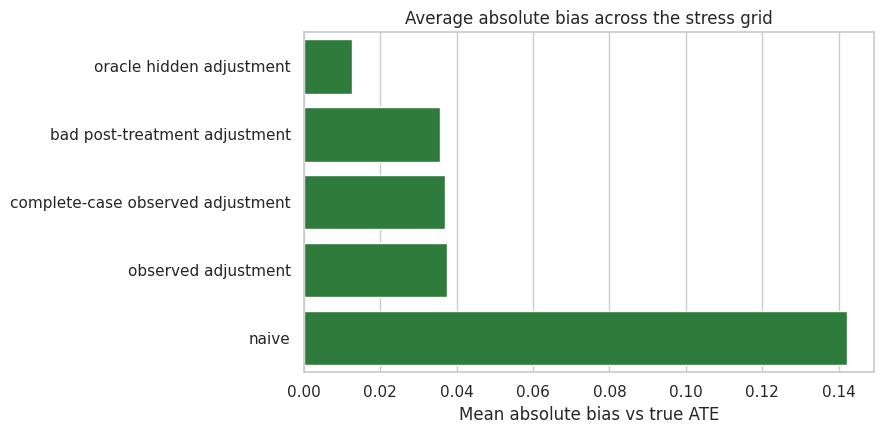

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=stress_summary, y='estimator', x='mean_absolute_bias', color='#228833', ax=ax)
ax.set_title('Average absolute bias across the stress grid')
ax.set_xlabel('Mean absolute bias vs true ATE')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The summary collapses the lab into one table. That is useful, but it can hide mechanisms. We should also look at how bias changes as each assumption knob moves.

Read Scenario Grid: Stress Multiple Assumptions as a draft from an unreliable assistant. The strongest parts are the ones an analyst can check. Missing assumptions, invented facts, and format drift point to the controls that need tightening.


## 9. Visualize Assumption Failure Modes

We now isolate patterns in the grid: hidden confounding, measurement error, and overlap.

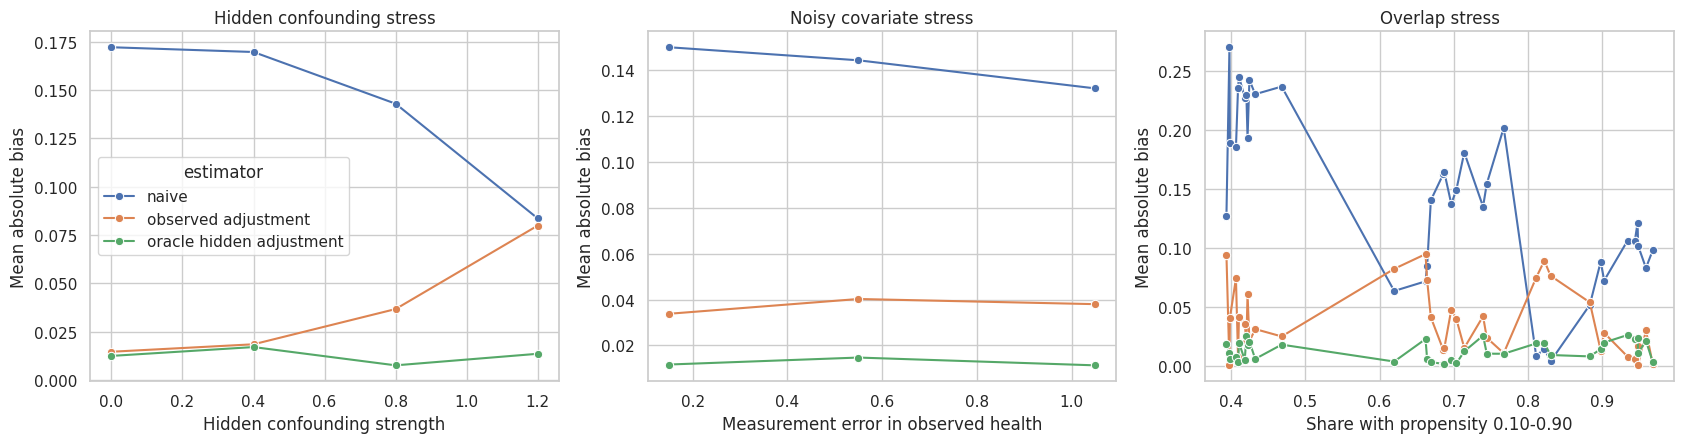

In [17]:
# Section focus: 9. Visualize Assumption Failure Modes.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

selected_estimators = ['naive', 'observed adjustment', 'oracle hidden adjustment']
plot_grid = stress_results.query('estimator in @selected_estimators').copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
sns.lineplot(
    data=plot_grid,
    x='unobserved_confounding_strength',
    y='absolute_bias',
    hue='estimator',
    marker='o',
    estimator='mean',
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title('Hidden confounding stress')
axes[0].set_xlabel('Hidden confounding strength')
axes[0].set_ylabel('Mean absolute bias')

sns.lineplot(
    data=plot_grid,
    x='measurement_error_sd',
    y='absolute_bias',
    hue='estimator',
    marker='o',
    estimator='mean',
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title('Noisy covariate stress')
axes[1].set_xlabel('Measurement error in observed health')
axes[1].set_ylabel('Mean absolute bias')
axes[1].legend_.remove()

sns.lineplot(
    data=plot_grid,
    x='overlap_share_10_to_90',
    y='absolute_bias',
    hue='estimator',
    marker='o',
    estimator='mean',
    errorbar=None,
    ax=axes[2],
)
axes[2].set_title('Overlap stress')
axes[2].set_xlabel('Share with propensity 0.10-0.90')
axes[2].set_ylabel('Mean absolute bias')
axes[2].legend_.remove()
plt.tight_layout()
plt.show()

The plot matters because it shows structure that a single summary number can hide. For Visualize Assumption Failure Modes, look for where groups separate, where curves bend, or where the tails behave differently. Those features should shape the next choice about model class, threshold, monitoring, or human review.


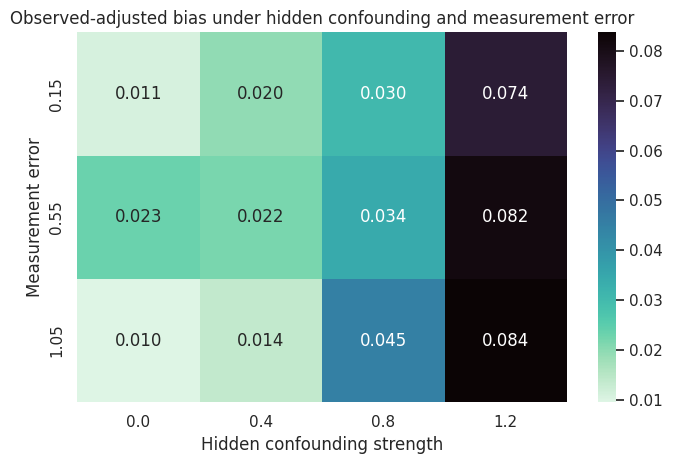

In [18]:
heatmap_data = (
    stress_results
    .query("estimator == 'observed adjustment'")
    .groupby(['unobserved_confounding_strength', 'measurement_error_sd'], as_index=False)
    .agg(mean_absolute_bias=('absolute_bias', 'mean'))
    .pivot(index='measurement_error_sd', columns='unobserved_confounding_strength', values='mean_absolute_bias')
)
fig, ax = plt.subplots(figsize=(7, 4.8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='mako_r', ax=ax)
ax.set_title('Observed-adjusted bias under hidden confounding and measurement error')
ax.set_xlabel('Hidden confounding strength')
ax.set_ylabel('Measurement error')
plt.tight_layout()
plt.show()

This is where simulation labs become useful for teaching. The observed adjustment model can do well when the observed covariates are good proxies and hidden confounding is weak. It becomes less reliable when hidden confounding is strong or the observed health score becomes noisy.

The oracle model is included to remind us what the observed analysis is missing. It is not available in a real project.

## 10. Selection and Interference Mini-Labs

The main grid held selection and spillover fixed. Now we vary those two assumptions directly.

In [19]:
# Section focus: 10. Selection and Interference Mini-Labs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

selection_rows = []
scenario_id = 0
for selection_strength in [0.0, 0.5, 1.0, 1.7]:
    scenario_id += 1
    sim_df, sim_truth = simulate_playbook_lab(
        n_accounts=4200,
        n_teams=70,
        seed=SEED + 500 + scenario_id,
        unobserved_confounding_strength=0.6,
        overlap_pressure=1.0,
        measurement_error_sd=0.45,
        selection_strength=selection_strength,
        spillover_strength=0.05,
    )
    estimates = estimate_scenario(sim_df, sim_truth)
    for _, row in estimates.iterrows():
        selection_rows.append({'selection_strength': selection_strength, **sim_truth, **row.to_dict()})
selection_results = pd.DataFrame(selection_rows)

spillover_rows = []
scenario_id = 0
for spillover_strength in [0.0, 0.04, 0.10, 0.18]:
    scenario_id += 1
    sim_df, sim_truth = simulate_playbook_lab(
        n_accounts=4200,
        n_teams=70,
        seed=SEED + 800 + scenario_id,
        unobserved_confounding_strength=0.6,
        overlap_pressure=1.0,
        measurement_error_sd=0.45,
        selection_strength=0.4,
        spillover_strength=spillover_strength,
    )
    estimates = estimate_scenario(sim_df, sim_truth)
    for _, row in estimates.iterrows():
        spillover_rows.append({'spillover_strength': spillover_strength, **sim_truth, **row.to_dict()})
spillover_results = pd.DataFrame(spillover_rows)

selection_results.head()

,selection_strength,true_ate,true_att,treatment_rate,complete_outcome_rate,overlap_share_10_to_90,estimator,rows_used,estimated_effect,robust_se,bias,absolute_bias,r_squared
0,0.0,0.015723,0.016239,0.736667,0.902857,0.695,naive,4200,-0.146891,0.017181,-0.162614,0.162614,0.016745
1,0.0,0.015723,0.016239,0.736667,0.902857,0.695,observed adjustment,4200,0.029059,0.017486,0.013336,0.013336,0.171581
2,0.0,0.015723,0.016239,0.736667,0.902857,0.695,oracle hidden adjustment,4200,0.006515,0.017273,-0.009208,0.009208,0.213411
3,0.0,0.015723,0.016239,0.736667,0.902857,0.695,bad post-treatment adjustment,4200,0.028025,0.018409,0.012301,0.012301,0.171588
4,0.0,0.015723,0.016239,0.736667,0.902857,0.695,complete-case observed adjustment,3792,0.028385,0.018278,0.012661,0.012661,0.174707


This table gives the quantitative checkpoint for Selection and Interference Mini-Labs. The table is useful when it clarifies a model choice, review priority, or guardrail. Instability in this table should turn into a review question before the result supports a real decision.


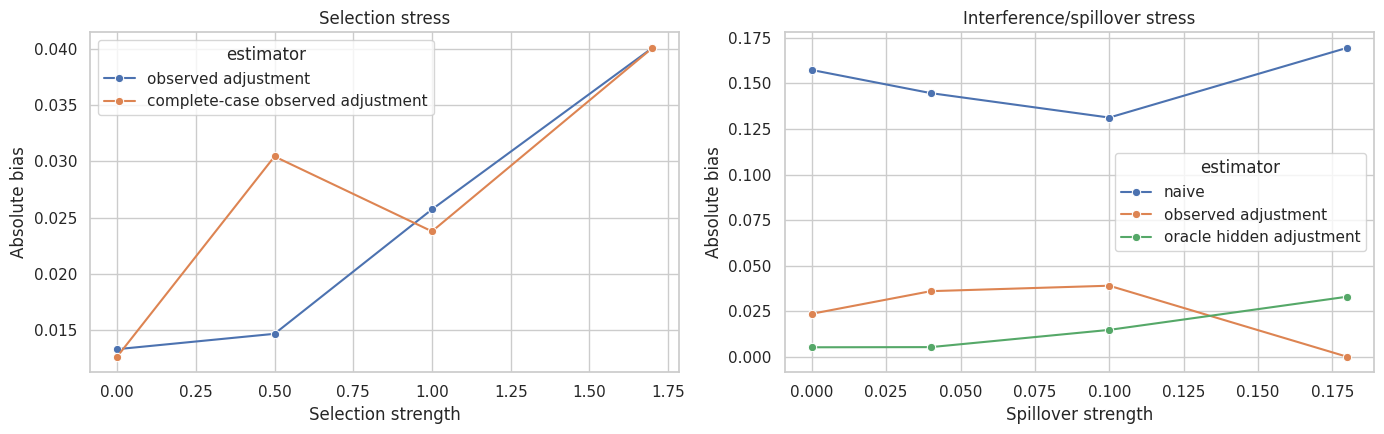

In [20]:
# Section focus: 10. Selection and Interference Mini-Labs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=selection_results.query("estimator in ['observed adjustment', 'complete-case observed adjustment']"),
    x='selection_strength',
    y='absolute_bias',
    hue='estimator',
    marker='o',
    estimator='mean',
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title('Selection stress')
axes[0].set_xlabel('Selection strength')
axes[0].set_ylabel('Absolute bias')

sns.lineplot(
    data=spillover_results.query("estimator in ['naive', 'observed adjustment', 'oracle hidden adjustment']"),
    x='spillover_strength',
    y='absolute_bias',
    hue='estimator',
    marker='o',
    estimator='mean',
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title('Interference/spillover stress')
axes[1].set_xlabel('Spillover strength')
axes[1].set_ylabel('Absolute bias')
plt.tight_layout()
plt.show()

Selection stress focuses on who has an observed outcome. Interference stress focuses on whether one account's outcome depends on treatment saturation in its team.

These are different assumptions. They call for different design fixes. Selection may require missing-data analysis, outcome capture redesign, or bounding. Interference may require cluster-level assignment, exposure mapping, or redefining the estimand.

## 11. Create an Assumption Lab Report

The lab report should summarize the scenario grid in a way that an analyst or stakeholder can understand. It should not bury the causal lesson under raw simulation output.

In [21]:
# Section focus: 11. Create an Assumption Lab Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def dataframe_records(df, max_rows=30):
    """Carry out the dataframe records step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    max_rows : object
        Maximum number of rows shown in a rendered table or diagnostic display.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the dataframe records workflow for later analysis.
    """
    return json.loads(df.head(max_rows).to_json(orient='records', date_format='iso'))

lab_report = {
    'lab_card': lab_card,
    'assumptions_stressed': dataframe_records(stress_test_dimensions, max_rows=20),
    'base_truth': base_truth,
    'base_estimator_results': dataframe_records(base_estimates, max_rows=20),
    'stress_grid_summary': dataframe_records(stress_summary, max_rows=20),
    'worst_observed_adjustment_cases': dataframe_records(
        stress_results.query("estimator == 'observed adjustment'").sort_values('absolute_bias', ascending=False),
        max_rows=10,
    ),
    'selection_stress_summary': dataframe_records(
        selection_results.groupby(['selection_strength', 'estimator'], as_index=False).agg(mean_absolute_bias=('absolute_bias', 'mean'), complete_outcome_rate=('complete_outcome_rate', 'mean')),
        max_rows=25,
    ),
    'spillover_stress_summary': dataframe_records(
        spillover_results.groupby(['spillover_strength', 'estimator'], as_index=False).agg(mean_absolute_bias=('absolute_bias', 'mean')),
        max_rows=25,
    ),
    'explicit_warnings': [
        'Oracle estimators use hidden variables and are not feasible in real production data.',
        'Observed adjustment can fail when hidden confounding or measurement error is strong.',
        'Complete-case analysis can target a selected population when outcome observation depends on treatment or renewal propensity.',
        'Spillovers require redefining exposure or assignment; ordinary individual-level estimators can mix direct and spillover effects.',
    ],
}

print(json.dumps(lab_report, indent=2)[:5000])

{
  "lab_card": {
    "title": "Customer-success playbook stress-test lab",
    "unit": "account",
    "cluster": "customer_success_team",
    "treatment": "playbook_assigned",
    "outcome": "renewed_90d",
    "estimand": "ATE of playbook_assigned on renewed_90d in the simulated account population",
    "observed_confounders": [
      "segment",
      "region",
      "account_size",
      "usage_trend",
      "support_tickets",
      "observed_health_score",
      "risk_score_observed"
    ],
    "hidden_variables": [
      "true_account_health",
      "executive_attention"
    ],
    "post_treatment_or_selection_variables": [
      "playbook_engagement",
      "expansion_call_completed",
      "outcome_observed"
    ],
    "simulation_warning": "Oracle variables are included for teaching only and would not be observed in a real analysis."
  },
  "assumptions_stressed": [
    {
      "assumption": "Conditional exchangeability",
      "stress knob": "unobserved_confounding_strength",
 

This report is the object we will give the LLM. The model should summarize the lab results, identify which assumptions are most fragile, and suggest additional stress tests. It should not claim the simulation validates the real intervention.

For Create an Assumption Lab Report, the table matters because it turns several options into a decision comparison. The row that changes a threshold or review priority deserves the closest look.


## 12. Shared Local LLM Runtime

We reuse the shared local LLM utilities from `notebooks/_shared` so model loading and decoding behavior stays consistent with previous notebooks.

In [22]:
# Section focus: 12. Shared Local LLM Runtime.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def find_project_root(start=None):
    """Carry out the find project root step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    start : object
        Starting index, time, or location for the simulated event window.
    
    Returns
    -------
    object
        Intermediate result produced by the find project root calculation and reused by later cells.
    """
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local chat step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local chat calculation and reused by later cells.
    """
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 13. Structured AI Lab Review

The model's job is to review the stress-test lab. It should identify assumption failures, interpret estimator behavior, and propose additional stress tests.

The schema makes the review auditable.

In [23]:
# Section focus: 13. Structured AI Lab Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class AssumptionLabReview(BaseModel):
    lab_goal: str = Field(description='The purpose of the simulation lab.')
    estimand: str = Field(description='The causal estimand being stress tested.')
    assumptions_stressed: list[str] = Field(description='Assumptions explicitly stressed in the lab.')
    most_fragile_assumptions: list[str] = Field(description='Assumptions that appear most consequential in the results.')
    estimator_interpretation: list[str] = Field(description='How each estimator behaved and why.')
    oracle_warning: str = Field(description='Warning about oracle estimators and hidden variables.')
    real_world_limitations: list[str] = Field(description='Why this simulation does not prove production impact.')
    recommended_next_stress_tests: list[str] = Field(description='Additional simulation checks worth adding.')
    stakeholder_summary: str = Field(description='Plain-language summary for nontechnical stakeholders.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the review given the lab report.')

REVIEW_SCALAR_FIELDS = ['lab_goal', 'estimand', 'oracle_warning', 'stakeholder_summary', 'confidence']
REVIEW_LIST_FIELDS = [
    'assumptions_stressed',
    'most_fragile_assumptions',
    'estimator_interpretation',
    'real_world_limitations',
    'recommended_next_stress_tests',
]
REVIEW_ALIASES = {
    'goal': 'lab_goal',
    'target_estimand': 'estimand',
    'fragile_assumptions': 'most_fragile_assumptions',
    'estimator_behavior': 'estimator_interpretation',
    'limitations': 'real_world_limitations',
    'next_stress_tests': 'recommended_next_stress_tests',
    'summary': 'stakeholder_summary',
}


def parse_lab_review(raw_output):
    """Carry out the parse lab review step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    result = parse_pydantic_output(
        raw_output,
        AssumptionLabReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        defaults={'confidence': 'medium'},
    )
    return result.parsed, result.json_text, result.notes

In [24]:
# Section focus: 13. Structured AI Lab Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference simulation-lab reviewer.\n'
    'Rules:\n'
    '- Use only the provided lab report.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Distinguish feasible observed estimators from oracle estimators that use hidden variables.\n'
    '- Do not claim the simulation proves the real intervention works.\n'
    '- Do not recommend hidden variables, potential outcomes, post-treatment variables, or selection indicators as ordinary real-world controls.\n'
    '- Mention brittleness and rerun sensitivity when appropriate.\n'
    '- Use exact assumption and estimator names whenever possible.'
)


def build_review_prompt(report):
    """Build the review prompt object used in the 12. Simulation Labs for Assumption Stress Testing analysis.
    
    Parameters
    ----------
    report : object
        Report text or report table being rendered, scored, or checked for completeness.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the review prompt workflow.
    """
    schema_hint = {
        'lab_goal': 'string',
        'estimand': 'string',
        'assumptions_stressed': ['string'],
        'most_fragile_assumptions': ['string'],
        'estimator_interpretation': ['string'],
        'oracle_warning': 'string',
        'real_world_limitations': ['string'],
        'recommended_next_stress_tests': ['string'],
        'stakeholder_summary': 'string',
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce an AssumptionLabReview JSON object using this schema:
        {json.dumps(schema_hint, indent=2)}

        Lab report:
        {json.dumps(report, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(lab_report)
print(review_prompt[:3000])

Produce an AssumptionLabReview JSON object using this schema:
        {
  "lab_goal": "string",
  "estimand": "string",
  "assumptions_stressed": [
    "string"
  ],
  "most_fragile_assumptions": [
    "string"
  ],
  "estimator_interpretation": [
    "string"
  ],
  "oracle_warning": "string",
  "real_world_limitations": [
    "string"
  ],
  "recommended_next_stress_tests": [
    "string"
  ],
  "stakeholder_summary": "string",
  "confidence": "low | medium | high"
}

        Lab report:
        {
  "lab_card": {
    "title": "Customer-success playbook stress-test lab",
    "unit": "account",
    "cluster": "customer_success_team",
    "treatment": "playbook_assigned",
    "outcome": "renewed_90d",
    "estimand": "ATE of playbook_assigned on renewed_90d in the simulated account population",
    "observed_confounders": [
      "segment",
      "region",
      "account_size",
      "usage_trend",
      "support_tickets",
      "observed_health_score",
      "risk_score_observed"
    ]

In Structured AI Lab Review, a good answer gives the analyst something to verify instead of a confident conclusion to accept.


## 14. Run One Local Model

We start with the fast local model. A good answer should preserve the difference between the simulated truth, feasible observed adjustment, and oracle diagnostics.

In [25]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    smart_display(Markdown('### Raw model output'))
    smart_display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "lab_goal": "Stress-test the robustness of different causal estimators for the effect of a customer success playbook on account renewals.",
 "estimand": "ATE of playbook_assigned on renewed_90d in the simulated account population",
 "assumptions_stressed": [
 "Conditional exchangeability",
 "Positivity / overlap",
 "Measurement validity",
 "No selection on post-treatment variables",
 "No interference"
 ],
 "most_fragile_assumptions": [
 "Conditional exchangeability",
 "Positivity / overlap"
 ],
 "estimator_interpretation": [
 "Naive estimator: Unadjusted for any confounders, highly biased.",
 "Observed adjustment: Adjusts for observed confounders, still biased but less so than naive.",
 "Oracle hidden adjustment: Uses unobserved confounders, unbiased but not feasible in practice.",
 "Bad post-treatment adjustment: Adjusts for post-treatment variables, introduces bias.",
 "Complete-case observed adjustment: Excludes cases where the outcome is missing, potentially biased."
 ],
 "oracle_warning": "Oracle estimators use hidden variables and are not feasible in real production data.",
 "real_world_limitations": [
 "Observed adjustment can fail when hidden confounding or measurement error is strong.",
 "Complete-case analysis can target a selected population when outcome observation depends on treatment or renewal propensity.",
 "Spillovers require redefining exposure or assignment; ordinary individual-level estimators can mix direct and spillover effects."
 ],
 "recommended_next_stress_tests": [
 "Increase the strength of unobserved confounding to see how it affects the estimators.",
 "Test different levels of overlap pressure to observe its impact on positivity and overlap assumptions.",
 "Explore the effect of varying measurement error on the estimators.",
 "Assess the robustness of estimators to different levels of selection on post-treatment variables.",
 "Investigate the impact of stronger spillover effects on the estimators."
 ],
 "stakeholder_summary": "This lab highlights the importance of carefully considering unobserved confounding, positivity, measurement validity, and selection on post-treatment variables when estimating the effect of a customer success playbook on account renewals. The results suggest that observed adjustment methods can be biased, and complete-case analysis may introduce selection bias. Oracle estimators, while unbiased, are not feasible in real-world settings. Stakeholders should be cautious about the assumptions underlying their causal inference and consider sensitivity analyses to understand the robustness of their findings.",
 "confidence": "medium"
}
```

The test in Run One Local Model is whether the model can help without blurring evidence and assumptions. When it fails, the repair should be concrete.


In [26]:
if raw_review_output:
    try:
        lab_review, lab_review_json, review_parser_notes = parse_lab_review(raw_review_output)
        single_model_parse_error = ''
        smart_display(Markdown('### Parsed lab review'))
        smart_display(Markdown(f'```json\n{lab_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        lab_review = None
        lab_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    lab_review = None
    lab_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

### Parsed lab review

```json
{
  "lab_goal": "Stress-test the robustness of different causal estimators for the effect of a customer success playbook on account renewals.",
  "estimand": "ATE of playbook_assigned on renewed_90d in the simulated account population",
  "assumptions_stressed": [
    "Conditional exchangeability",
    "Positivity / overlap",
    "Measurement validity",
    "No selection on post-treatment variables",
    "No interference"
  ],
  "most_fragile_assumptions": [
    "Conditional exchangeability",
    "Positivity / overlap"
  ],
  "estimator_interpretation": [
    "Naive estimator: Unadjusted for any confounders, highly biased.",
    "Observed adjustment: Adjusts for observed confounders, still biased but less so than naive.",
    "Oracle hidden adjustment: Uses unobserved confounders, unbiased but not feasible in practice.",
    "Bad post-treatment adjustment: Adjusts for post-treatment variables, introduces bias.",
    "Complete-case observed adjustment: Excludes cases where the outcome is missing, potentially biased."
  ],
  "oracle_warning": "Oracle estimators use hidden variables and are not feasible in real production data.",
  "real_world_limitations": [
    "Observed adjustment can fail when hidden confounding or measurement error is strong.",
    "Complete-case analysis can target a selected population when outcome observation depends on treatment or renewal propensity.",
    "Spillovers require redefining exposure or assignment; ordinary individual-level estimators can mix direct and spillover effects."
  ],
  "recommended_next_stress_tests": [
    "Increase the strength of unobserved confounding to see how it affects the estimators.",
    "Test different levels of overlap pressure to observe its impact on positivity and overlap assumptions.",
    "Explore the effect of varying measurement error on the estimators.",
    "Assess the robustness of estimators to different levels of selection on post-treatment variables.",
    "Investigate the impact of stronger spillover effects on the estimators."
  ],
  "stakeholder_summary": "This lab highlights the importance of carefully considering unobserved confounding, positivity, measurement validity, and selection on post-treatment variables when estimating the effect of a customer success playbook on account renewals. The results suggest that observed adjustment methods can be biased, and complete-case analysis may introduce selection bias. Oracle estimators, while unbiased, are not feasible in real-world settings. Stakeholders should be cautious about the assumptions underlying their causal inference and consider sensitivity analyses to understand the robustness of their findings.",
  "confidence": "medium"
}
```

Parser notes: []


This table turns the design into specific items the analyst can review. For Run One Local Model, the important reading is the pattern across rows, the pattern across rows together with the largest values. If the pattern is useful, it should guide the next review.


## 15. Audit the AI Lab Review

A good review must preserve the lab's core causal lessons. It should name the assumptions, warn about oracle estimators, avoid production overclaiming, and suggest meaningful next stress tests.

In [27]:
# Section focus: 15. Audit the AI Lab Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def review_text(review):
    """Carry out the review text step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    review : object
        Reviewer text or model-generated critique being parsed, scored, or summarized.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the review text workflow.
    """
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    """Carry out the contains any step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    terms : object
        Search terms, concept terms, or model-output terms being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the contains any calculation and reused by later cells.
    """
    return any(term.lower() in text for term in terms)


def score_lab_review(review):
    """Score lab review for the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    review : object
        Reviewer text or model-generated critique being parsed, scored, or summarized.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    text = review_text(review)
    checks = {
        'states lab goal': contains_any(text, ['stress', 'assumption', 'simulation lab']),
        'states estimand': 'playbook_assigned' in text and 'renewed_90d' in text and 'ate' in text,
        'names hidden confounding': contains_any(text, ['hidden confounding', 'unobserved confounding', 'executive_attention']),
        'names overlap or positivity': contains_any(text, ['overlap', 'positivity', 'propensity']),
        'names measurement error': contains_any(text, ['measurement error', 'observed_health_score', 'noisy']),
        'names selection': contains_any(text, ['selection', 'complete-case', 'outcome_observed']),
        'names interference or spillover': contains_any(text, ['interference', 'spillover', 'team_treatment_rate']),
        'warns oracle is not feasible': contains_any(text, ['oracle', 'hidden variables', 'not feasible', 'not observed']),
        'does not overclaim production effect': not contains_any(text, ['proves the intervention works', 'production impact is established', 'real-world effect is proven']),
        'mentions observed adjustment limits': contains_any(text, ['observed adjustment', 'observed-adjusted', 'noisy proxy', 'residual confounding']),
        'suggests additional stress tests': len(review.recommended_next_stress_tests) >= 2 if review is not None else False,
        'includes stakeholder summary': bool(review.stakeholder_summary.strip()) if review is not None else False,
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit)

if lab_review is not None:
    single_audit, single_score, single_max_score = score_lab_review(lab_review)
    print(f'Score: {single_score}/{single_max_score}')
    smart_display(single_audit)
else:
    print('No lab review to audit because live model execution was skipped or parsing failed.')

Score: 12/12


,check,passed,credit
0,states lab goal,True,1
1,states estimand,True,1
2,names hidden confounding,True,1
3,names overlap or positivity,True,1
4,names measurement error,True,1
5,names selection,True,1
6,names interference or spillover,True,1
7,warns oracle is not feasible,True,1
8,does not overclaim production effect,True,1
9,mentions observed adjustment limits,True,1


The audit is intentionally practical. We care less about whether the model writes elegant prose and more about whether it preserves the boundary between simulation evidence and production evidence.

If a model misses interference or treats the oracle estimator as a real option, that is a teaching signal.

## 16. Optional All-Model Comparison

We now run the same lab-review prompt across all local models.

The exact ranking can change across reruns and environments. That is expected. The durable lesson is to compare models on the same structured task and record failure metadata instead of letting brittle outputs disappear into prose.

In [28]:
# Section focus: 16. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

LAB_EVAL_CASES = [
    {
        'case_id': 'customer_success_assumption_lab_review',
        'report': lab_report,
    }
]

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used',
    'repair_stage', 'error_type', 'review_score', 'max_review_score', 'review_score_share',
    'error', 'raw_output_preview'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required AssumptionLabReview JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_lab_review():
    """Carry out the empty lab review step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the empty lab review workflow.
    """
    return AssumptionLabReview(
        lab_goal='',
        estimand='',
        assumptions_stressed=[],
        most_fragile_assumptions=[],
        estimator_interpretation=[],
        oracle_warning='',
        real_world_limitations=[],
        recommended_next_stress_tests=[],
        stakeholder_summary='',
        confidence='low',
    )


def parse_or_repair_review(raw_output, model_id):
    """Carry out the parse or repair review step used in the 12. Simulation Labs for Assumption Stress Testing workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_lab_review(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_lab_review(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_review_case(label, model_id, role, case):
    """Run the single model review case workflow for the 12. Simulation Labs for Assumption Stress Testing analysis.
    
    Parameters
    ----------
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    role : object
        Workflow role assigned to an agent, variable, or review component.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    prompt = build_review_prompt(case['report'])
    raw_output = ''
    max_score = score_lab_review(empty_lab_review())[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_review(raw_output, model_id)
        audit, score, max_score = score_lab_review(parsed_result['parsed'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'review_score': score,
            'max_review_score': max_score,
            'review_score_share': score / max_score if max_score else 0.0,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'review_score': 0,
            'max_review_score': max_score,
            'review_score_share': 0.0,
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    """Summarize model results for the 12. Simulation Labs for Assumption Stress Testing analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_review_score=('review_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_review_comparison(models_to_compare=MODELS_TO_COMPARE, cases=LAB_EVAL_CASES):
    """Run the all model review comparison workflow for the 12. Simulation Labs for Assumption Stress Testing analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_review_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    lab_model_summary, lab_case_results = run_all_model_review_comparison()
else:
    lab_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    lab_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

smart_display(lab_model_summary)

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.0,1.000000,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,0,1.0,1.000000,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,0,1.0,1.000000,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.0,1.000000,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,1,0,1.0,1.000000,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,0,1.0,1.000000,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,0,1.0,1.000000,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,0,1.0,1.000000,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,1,1.0,0.916667,[]


This step in Optional All-Model Comparison is a reliability test. A polished answer is not enough; it has to be anchored.


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. This is especially important in simulation-lab review because brittle model outputs can otherwise look like missing data rather than model failures.

In [29]:
failed_model_details = lab_case_results.loc[
    ~lab_case_results['schema_valid'],
    ['label', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
smart_display(failed_model_details)

,label,status,error_type,error,raw_output_preview


For Inspecting Failed Model Runs, treat the response as a small experiment in model behavior. Separate the useful structure from the reliability problems.


### Interpreting Repair Counts

Repairs are diagnostic signals. They indicate how much cleanup was needed before the output became usable. A model that needs repair may still reason well, but it is less reliable as an automated component.

In [30]:
def summarize_repair_stages(case_results):
    """Summarize repair stages for the 12. Simulation Labs for Assumption Stress Testing analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(lab_case_results)

,repair_stage,cases
0,none,6
1,parser,3


In Interpreting Repair Counts, trust comes from keeping the causal pieces visible: estimand, timing, assumptions, diagnostics, and limits.


## 17. Reusable Assumption Stress-Test Checklist

A simulation lab should make the following pieces explicit.

| check | example from notebook |
|---|---|
| Estimand is explicit | ATE of playbook_assigned on renewed_90d |
| Stress knobs map to named assumptions | hidden confounding, overlap, measurement error, selection, spillover |
| Ground truth is computed from potential outcomes | p1_renewal - p0_renewal |
| Feasible and oracle estimators are separated | observed adjustment vs oracle hidden adjustment |
| Invalid specifications are labeled as teaching tools | bad post-treatment adjustment |
| Scenario grid reports bias, alongside fitted coefficients | absolute_bias in stress_results |
| Selection and interference receive separate diagnostics | selection_results and spillover_results |
| AI review is audited against known assumptions | score_lab_review |


## 18. Exercises

1. Add treatment-effect heterogeneity as a sixth stress knob and plot when ATE and ATT diverge.
2. Replace the linear probability estimator with inverse propensity weighting using the true propensity and an estimated propensity. Compare both against truth.
3. Add a cluster-level assignment scenario and compare account-level versus cluster-level estimands.
4. Increase measurement error until observed adjustment performs almost like the naive estimator. Explain why.
5. Ask one local model to propose a new stress-test dimension, then decide whether the proposal maps to a named causal assumption.
6. Remove the oracle warning from the lab report and rerun the model comparison. Do any models treat oracle adjustment as feasible?

## Key Takeaways

Simulation labs turn assumptions into experiments.

A strong assumption stress-testing workflow has this shape:

1. Name the estimand.
2. Name the assumptions.
3. Build one stress knob per assumption.
4. Compute ground truth from potential outcomes.
5. Compare feasible, oracle, and intentionally invalid estimators.
6. Visualize bias as assumptions degrade.
7. Use AI to summarize and critique the lab, then audit whether it preserved the causal boundaries.

The deeper habit is not “trust the simulation.” The habit is “make every assumption visible enough that it can be stressed.”

## References

- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Imbens, G. W., & Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge University Press. [https://doi.org/10.1017/CBO9781139025751](https://doi.org/10.1017/CBO9781139025751)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology*, 66(5), 688-701. [https://doi.org/10.1037/h0037350](https://doi.org/10.1037/h0037350)
